# This notebook will be used to create a data preprocessing pipeline

In [2]:
# imports
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import matplotlib.pyplot as plt
import numpy as np
from scipy.fft import fft, fftfreq
from scipy import signal as sg
from scipy.stats import skew, kurtosis
from scipy.integrate import trapezoid
from sklearn.decomposition import PCA

# Load in the data

In [86]:
data_good = pd.read_csv(r"C:\Users\20223883\OneDrive - TU Eindhoven\Desktop\Uni\Master\5ARE0 Data analysis and learning methods\5ARE0-cycling-assignment\data\1_Goede_weg_ah_1\Accelerometer.csv")
data_bad = pd.read_csv(r"C:\Users\20223883\OneDrive - TU Eindhoven\Desktop\Uni\Master\5ARE0 Data analysis and learning methods\5ARE0-cycling-assignment\data\2_lievendaalseweg_tot_deel_loeffstraat-2026-09-19_06-33-01\Accelerometer.csv")

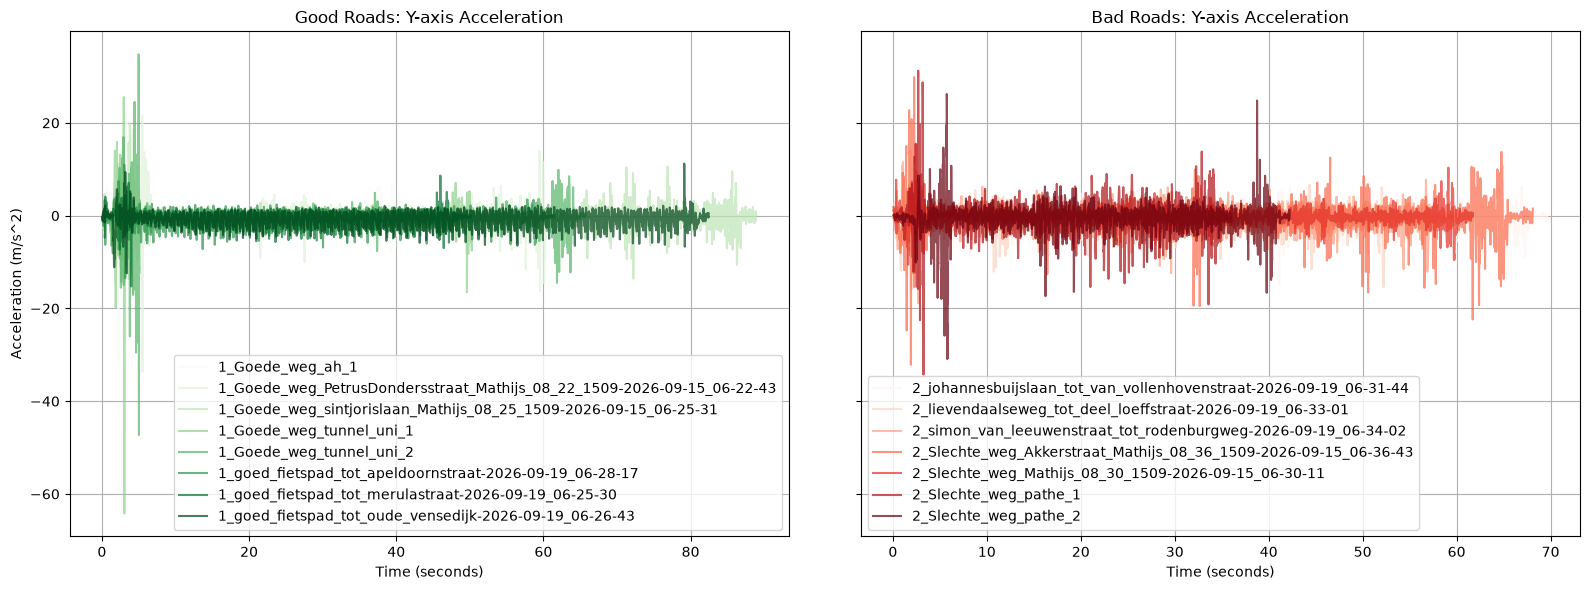

In [ ]:
# Automatically discover all good roads (starting with "1") and bad roads (starting with "2")
good_paths = glob.glob("data/1_*/**/Accelerometer.csv", recursive=True)
if not good_paths:
    good_paths = glob.glob("data/1_*/Accelerometer.csv")

bad_paths = glob.glob("data/2_*/**/Accelerometer.csv", recursive=True)
if not bad_paths:
    bad_paths = glob.glob("data/2_*/Accelerometer.csv")

# Create a figure with 2 subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Generate distinct shades of green for good roads dynamically
good_colors = plt.cm.Greens(
    [i / max(1, len(good_paths) - 1) for i in range(len(good_paths))]
)

# Plot all good road recordings
for path, color in zip(good_paths, good_colors):
    df = pd.read_csv(path)
    # Extract folder name to use as a dynamic label
    label = path.split(os.sep)[-2]
    ax1.plot(df['seconds_elapsed'], df['y'], label=label, color=color, alpha=0.7)

ax1.set_title("Good Roads: Y-axis Acceleration")
ax1.set_xlabel("Time (seconds)")
ax1.set_ylabel("Acceleration (m/s^2)")
ax1.legend()
ax1.grid(True)

# Generate distinct shades of red for bad roads dynamically
bad_colors = plt.cm.Reds(
    [i / max(1, len(bad_paths) - 1) for i in range(len(bad_paths))]
)

# Plot all bad road recordings
for path, color in zip(bad_paths, bad_colors):
    df = pd.read_csv(path)
    label = path.split(os.sep)[-2]
    ax2.plot(df['seconds_elapsed'], df['y'], label=label, color=color, alpha=0.7)

ax2.set_title("Bad Roads: Y-axis Acceleration")
ax2.set_xlabel("Time (seconds)")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

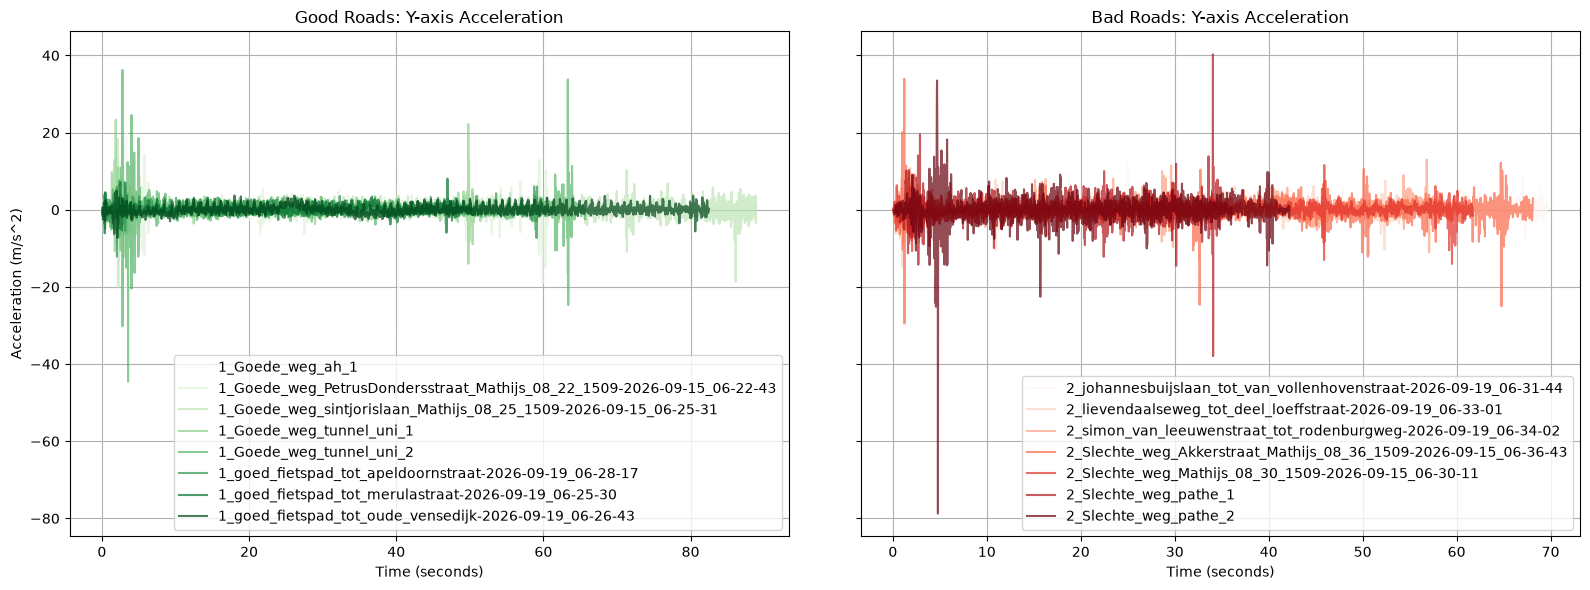

In [4]:
# Automatically discover all good roads (starting with "1") and bad roads (starting with "2")
good_paths = glob.glob("data/1_*/**/Accelerometer.csv", recursive=True)
if not good_paths:
    good_paths = glob.glob("data/1_*/Accelerometer.csv")

bad_paths = glob.glob("data/2_*/**/Accelerometer.csv", recursive=True)
if not bad_paths:
    bad_paths = glob.glob("data/2_*/Accelerometer.csv")

# Create a figure with 2 subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Generate distinct shades of green for good roads dynamically
good_colors = plt.cm.Greens(
    [i / max(1, len(good_paths) - 1) for i in range(len(good_paths))]
)

# Plot all good road recordings
for path, color in zip(good_paths, good_colors):
    df = pd.read_csv(path)
    # Extract folder name to use as a dynamic label
    label = path.split(os.sep)[-2]
    ax1.plot(df['seconds_elapsed'], df['z'], label=label, color=color, alpha=0.7)

ax1.set_title("Good Roads: Y-axis Acceleration")
ax1.set_xlabel("Time (seconds)")
ax1.set_ylabel("Acceleration (m/s^2)")
ax1.legend()
ax1.grid(True)

# Generate distinct shades of red for bad roads dynamically
bad_colors = plt.cm.Reds(
    [i / max(1, len(bad_paths) - 1) for i in range(len(bad_paths))]
)

# Plot all bad road recordings
for path, color in zip(bad_paths, bad_colors):
    df = pd.read_csv(path)
    label = path.split(os.sep)[-2]
    ax2.plot(df['seconds_elapsed'], df['z'], label=label, color=color, alpha=0.7)

ax2.set_title("Bad Roads: Y-axis Acceleration")
ax2.set_xlabel("Time (seconds)")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

# Cut and synchronize data

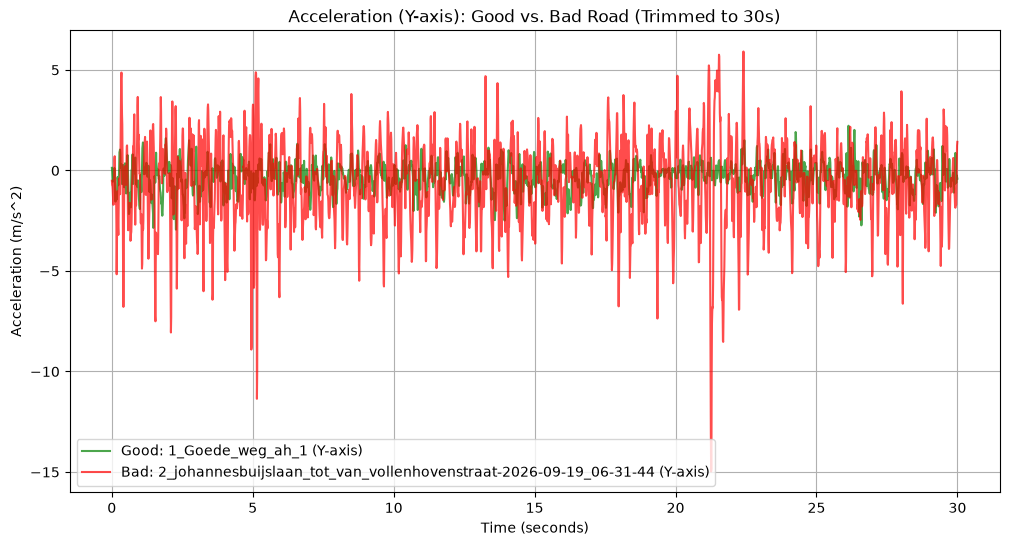

In [19]:
def trim_to_30s(df):
    """Trims dataframe symmetrically to a duration of 30 seconds."""
    start_time = df['seconds_elapsed'].min()
    end_time = df['seconds_elapsed'].max()
    total_duration = end_time - start_time
    
    if total_duration > 30:
        trim_amount = (total_duration - 30) / 2
        new_start = start_time + trim_amount
        new_end = end_time - trim_amount
        
        # Filter rows within the 30-second window and reset elapsed time from 0
        df_trimmed = df[(df['seconds_elapsed'] >= new_start) & (df['seconds_elapsed'] <= new_end)].copy()
        df_trimmed['seconds_elapsed'] = df_trimmed['seconds_elapsed'] - new_start
        return df_trimmed
    return df

# Process and trim all discovered good road recordings dynamically
good_roads_trimmed = {}
for path in good_paths:
    key = path.split(os.sep)[-2]
    df = pd.read_csv(path)
    good_roads_trimmed[key] = trim_to_30s(df)

# Process and trim all discovered bad road recordings dynamically
bad_roads_trimmed = {}
for path in bad_paths:
    key = path.split(os.sep)[-2]
    df = pd.read_csv(path)
    bad_roads_trimmed[key] = trim_to_30s(df)

# Plotting example: Y-axis comparison of a sample good and bad road after trimming
plt.figure(figsize=(12, 6))

if good_roads_trimmed:
    first_good_key = list(good_roads_trimmed.keys())[0]
    df_g = good_roads_trimmed[first_good_key]
    plt.plot(df_g['seconds_elapsed'], df_g['y'], label=f'Good: {first_good_key} (Y-axis)', color='green', alpha=0.7)

if bad_roads_trimmed:
    first_bad_key = list(bad_roads_trimmed.keys())[0]
    df_b = bad_roads_trimmed[first_bad_key]
    plt.plot(df_b['seconds_elapsed'], df_b['y'], label=f'Bad: {first_bad_key} (Y-axis)', color='red', alpha=0.7)

plt.title('Acceleration (Y-axis): Good vs. Bad Road (Trimmed to 30s)')
plt.xlabel('Time (seconds)')
plt.ylabel('Acceleration (m/s^2)')
plt.legend()
plt.grid(True)
plt.show()

# Preprocess the data

In [21]:
# 1. Bandpass filter definitions
def butter_bandpass(lowcut, highcut, fs, order=4):
    """Design a Butterworth bandpass filter."""
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = sg.butter(order, [low, high], btype='band')
    return b, a

def bandpass_filter(data, lowcut, highcut, fs, order=4):
    """Apply the bandpass filter to a data array."""
    b, a = butter_bandpass(lowcut, highcut, fs, order=order)
    return sg.lfilter(b, a, data)

# 2. Windowing and Feature Extraction function (including Skewness & Kurtosis)
def create_windows_and_filter(df, window_size_sec=2.0, overlap=0.5, fs=100.0):
    """Apply sliding windows and extract statistical features from the Y-axis."""
    df_filtered = df.copy()
    # Apply bandpass filter to the Y-axis
    df_filtered['y_filtered'] = bandpass_filter(df['y'], lowcut=0.5, highcut=20.0, fs=fs)
    df_filtered['z_filtered'] = bandpass_filter(df['z'], lowcut=0.5, highcut=20.0, fs=fs)
    
    window_size_samples = int(window_size_sec * fs)
    step_size = int(window_size_samples * (1 - overlap))
    
    features_list = []
    window_list = []
    
    for start in range(0, len(df_filtered) - window_size_samples, step_size):
        window = df_filtered.iloc[start:start + window_size_samples]
        sig_y = window['y_filtered']
        sig_z = window['z_filtered']
        
        # Extract features per window
        feat = {
            'mean': sig_y.mean(),
            'std': sig_y.std(),
            'rms': np.sqrt(np.mean(sig_y**2)),
            'peak_to_peak': sig_y.max() - sig_y.min(),
            'iqr': np.percentile(sig_y, 75) - np.percentile(sig_y, 25),
            'skewness': skew(sig_y),
            'kurtosis': kurtosis(sig_y)
        }
        features_list.append(feat)

        window = {
            'window_start_idx': start,
            'raw_signal': sig_y.values,  # stores the full array in one cell
            'mean': sig_y.mean(),
            'std': sig_y.std(),
                            }
        window_list.append(window)
        
    return pd.DataFrame(features_list),  pd.DataFrame(window_list)

# 3. Process ALL trimmed good roads and combine them into a single master dataframe
all_good_features = []
all_good_windows = []
for key, df_trimmed in good_roads_trimmed.items():
    feat_df, window_df = create_windows_and_filter(df_trimmed)
    feat_df['source'] = key
    window_df['source'] = key
    all_good_features.append(feat_df)
    all_good_windows.append(window_df)

features_good = pd.concat(all_good_features, ignore_index=True)
windows_good = pd.concat(all_good_windows, ignore_index=True)

# 4. Process ALL trimmed bad roads and combine them into a single master dataframe
all_bad_features = []
all_bad_windows = []
for key, df_trimmed in bad_roads_trimmed.items():
    feat_df, window_df = create_windows_and_filter(df_trimmed)
    feat_df['source'] = key
    window_df['source'] = key
    all_bad_features.append(feat_df)
    all_bad_windows.append(window_df)

features_bad = pd.concat(all_bad_features, ignore_index=True)
windows_bad = pd.concat(all_bad_windows, ignore_index=True)

# 5. Display summary results
print(f"Total feature windows generated for good roads: {len(features_good)}")
print(f"Total feature windows generated for bad roads: {len(features_bad)}")
print("\nFeature sample preview (Good roads):\n", features_good.head(3))

Total feature windows generated for good roads: 232
Total feature windows generated for bad roads: 203

Feature sample preview (Good roads):
        mean       std       rms  peak_to_peak       iqr  skewness  kurtosis  \
0  0.049653  0.808794  0.808296      3.658493  1.092390  0.302002 -0.435841   
1  0.006411  0.944952  0.942608      4.023340  1.438405  0.233579 -0.786159   
2 -0.035088  0.830046  0.828711      3.944835  1.064213 -0.098178 -0.296823   

             source  
0  1_Goede_weg_ah_1  
1  1_Goede_weg_ah_1  
2  1_Goede_weg_ah_1  


In [24]:
# Check out some stats for the dataframes
windows_bad.notna().count()

window_start_idx    203
raw_signal          203
mean                203
std                 203
source              203
dtype: int64

# Average sliced signals using rolling average

In [40]:
def rolling_average(arr, window_size):
    return pd.Series(arr).rolling(window=window_size, min_periods=1).mean().to_numpy()

window_size = 10
windows_good['averaged_signal'] = windows_good['raw_signal'].apply(lambda arr: rolling_average(arr, window_size=window_size))
windows_bad['averaged_signal'] = windows_bad['raw_signal'].apply(lambda arr: rolling_average(arr, window_size=window_size))


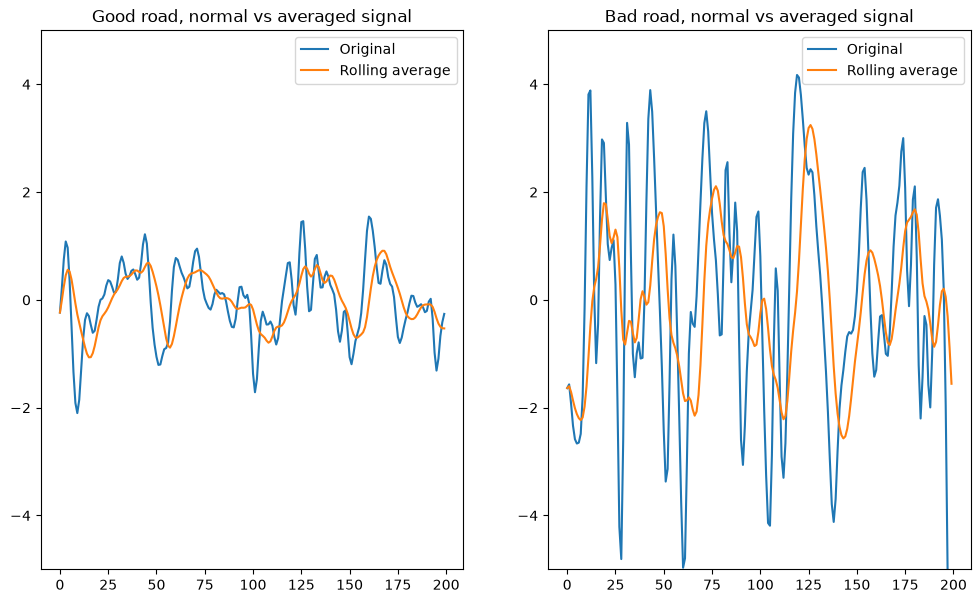

In [41]:
fig, ax = plt.subplots(ncols=2, figsize=(12, 7))
ax[0].plot(windows_good['raw_signal'][3])
ax[0].plot(windows_good['averaged_signal'][3])
ax[0].set_ylim([-5, 5])
ax[0].set_title("Good road, normal vs averaged signal")
ax[0].legend(['Original', 'Rolling average'])

ax[1].plot(windows_bad['raw_signal'][3])
ax[1].plot(windows_bad['averaged_signal'][3])
ax[1].set_ylim([-5, 5])
ax[1].set_title("Bad road, normal vs averaged signal")
ax[1].legend(['Original', 'Rolling average'])

# Scaling data

In [ ]:
scaler = MinMaxScaler()

total_averaged_bad = []
total_averaged_good = []
for i in range(len(windows_good['raw_signal'])):
    total_averaged_good.append(windows_good['averaged_signal'][i])

for i in range(len(windows_bad['raw_signal'])):
    total_averaged_bad.append(windows_bad['averaged_signal'][i])

,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False
Name,Type,Value
"data_max_ data_max_: ndarray of shape (n_features,)Per feature maximum seen in the data.. versionadded:: 0.17 *data_max_*","ndarray[float64](200,)","[3.91,3.98,3.82,...,2.44,2.31,2.39]"
"data_min_ data_min_: ndarray of shape (n_features,)Per feature minimum seen in the data.. versionadded:: 0.17 *data_min_*","ndarray[float64](200,)","[-3.62,-3.47,-3.08,...,-2.21,-2.42,-2.5 ]"
"data_range_ data_range_: ndarray of shape (n_features,)Per feature range ``(data_max_ - data_min_)`` seen in the data.. versionadded:: 0.17 *data_range_*","ndarray[float64](200,)","[7.53,7.45,6.9 ,...,4.65,4.74,4.88]"
"min_ min_: ndarray of shape (n_features,)Per feature adjustment for minimum. Equivalent to``min - X.min(axis=0) * self.scale_``","ndarray[float64](200,)","[0.48,0.47,0.45,...,0.48,0.51,0.51]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,200
"n_samples_seen_ n_samples_seen_: intThe number of samples processed by the estimator.It will be reset on new calls to fit, but increments across``partial_fit`` calls.",int,232
"scale_ scale_: ndarray of shape (n_features,)Per feature relative scaling of the data. Equivalent to``(max - min) / (X.max(axis=0) - X.min(axis=0))``.. versionadded:: 0.17 *scale_* attribute.","ndarray[float64](200,)","[0.13,0.13,0.14,...,0.22,0.21,0.2 ]"


# Look at frequency contents of signals

(0.0, 0.35)

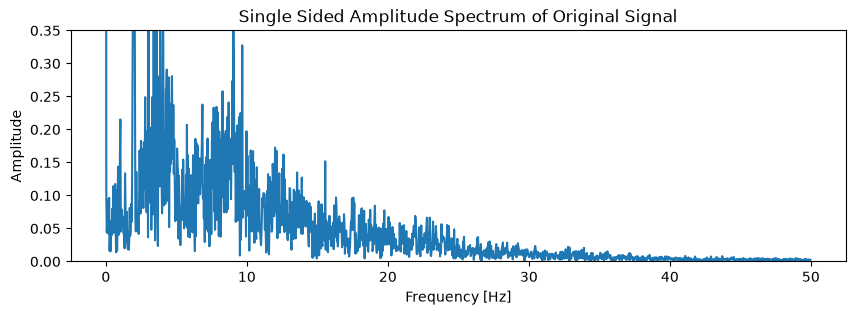

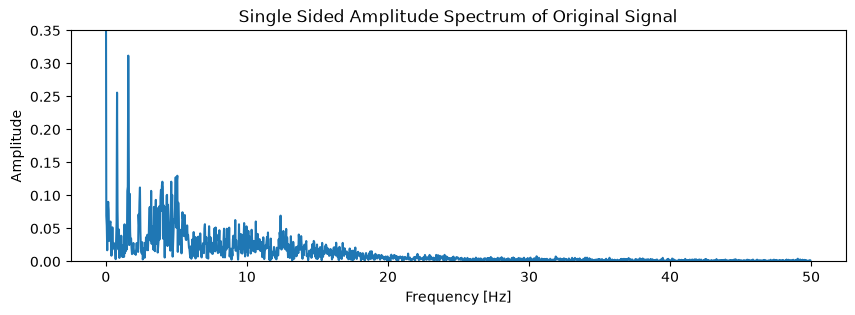

In [ ]:
# Plotting bad frequency signal
fs = 100 # Hz
N = len(bad_roads_trimmed[bad_paths[2].split(os.sep)[-2]]['y'])

zf = fft(bad_roads_trimmed[bad_paths[2].split(os.sep)[-2]]['y'])
xf = fftfreq(N, 1/fs)

# 4. Plot the single sided frequency/amplitude spectrum
plt.figure(figsize=(10, 3))
plt.plot(xf[:N//2], 2.0/N * abs(zf[:N//2]))
plt.xlabel('Frequency [Hz]')
plt.ylabel('Amplitude')
plt.title('Single Sided Amplitude Spectrum of Original Signal')
plt.ylim(0, 0.35)

# Plotting good frequency signal
fs = 100 # Hz
N = len(good_roads_trimmed[good_paths[2].split(os.sep)[-2]]['y'])

zf = fft(good_roads_trimmed[good_paths[2].split(os.sep)[-2]]['y'])
xf = fftfreq(N, 1/fs)

# 4. Plot the single sided frequency/amplitude spectrum
plt.figure(figsize=(10, 3))
plt.plot(xf[:N//2], 2.0/N * abs(zf[:N//2]))
plt.xlabel('Frequency [Hz]')
plt.ylabel('Amplitude')
plt.title('Single Sided Amplitude Spectrum of Original Signal')
plt.ylim(0, 0.35)

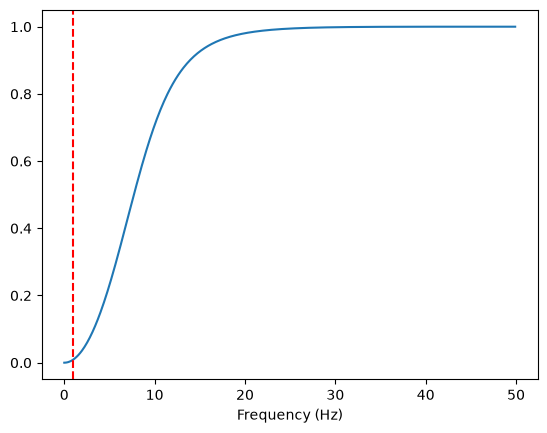

In [216]:
# Producing the filter and looking at its characteristics
cutoff_frequency = 10
nyq = 50

b, a = sg.butter(2, cutoff_frequency/nyq, btype='high')

w, h = sg.freqz(b, a, fs=fs)
plt.plot(w, abs(h))
plt.xlabel('Frequency (Hz)')
plt.axvline(1, color='r', linestyle='--')

(0.0, 0.35)

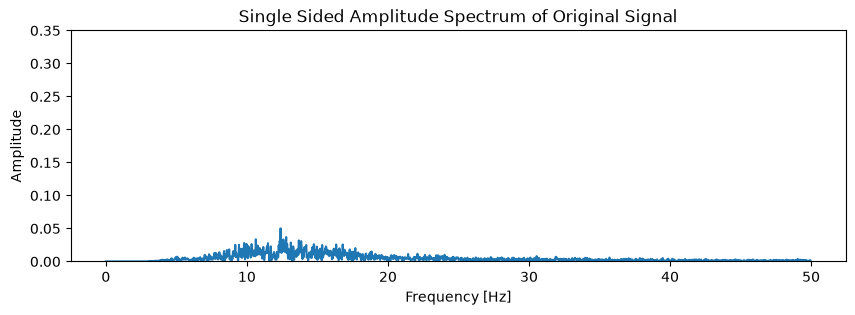

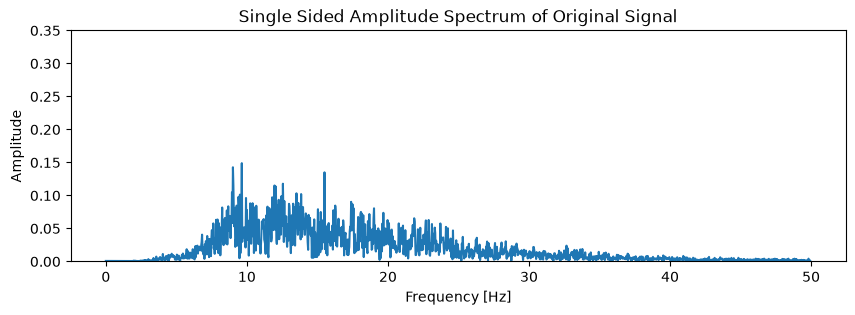

In [ ]:
# Visualization of two of the signals
filtered_good = sg.filtfilt(b, a, good_roads_trimmed[good_paths[2].split(os.sep)[-2]]['y'])
filtered_bad = sg.filtfilt(b, a, bad_roads_trimmed[bad_paths[2].split(os.sep)[-2]]['y'])

zf = fft(filtered_good)
xf = fftfreq(N, 1/fs)

# 4. Plot the single sided frequency/amplitude spectrum
plt.figure(figsize=(10, 3))
plt.plot(xf[:N//2], 2.0/N * abs(zf[:N//2]))
plt.xlabel('Frequency [Hz]')
plt.ylabel('Amplitude')
plt.title('Single Sided Amplitude Spectrum of Original Signal')
plt.ylim(0, 0.35)

zf = fft(filtered_bad)
xf = fftfreq(N, 1/fs)

# 4. Plot the single sided frequency/amplitude spectrum
plt.figure(figsize=(10, 3))
plt.plot(xf[:N//2], 2.0/N * abs(zf[:N//2]))
plt.xlabel('Frequency [Hz]')
plt.ylabel('Amplitude')
plt.title('Single Sided Amplitude Spectrum of Original Signal')
plt.ylim(0, 0.35)

In [ ]:
# Visualization of signal after filtering
fig, ax = plt.subplots(ncols=2, figsize=(12,5))
ax[0].plot(filtered_good)

ax[1].plot(filtered_bad)

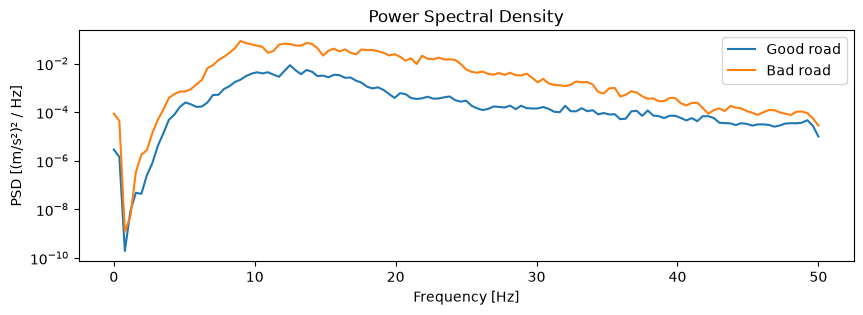

In [ ]:
# Create spectral density plots and visualize
f_good, Pxx_good = sg.welch(filtered_good, fs=fs, nperseg=256)
f_bad, Pxx_bad = sg.welch(filtered_bad, fs=fs, nperseg=256)

plt.figure(figsize=(10, 3))
plt.semilogy(f_good, Pxx_good, label='Good road')
plt.semilogy(f_bad, Pxx_bad, label='Bad road')
plt.xlabel('Frequency [Hz]')
plt.ylabel('PSD [(m/s²)² / Hz]')  # see units section below
plt.title('Power Spectral Density')
plt.legend()

# Calculate the integrals of the signals
mask = (f_good >= 20) & (f_good <= 80)
power_good = trapezoid(Pxx_good[mask], f_good[mask])
power_good

power_bad = trapezoid(Pxx_bad[mask], f_bad[mask])
power_bad- power_good

In [257]:
# Apply filtering to all total signals and integrate over each individual window
def filter_signals(signal_dict, b, a, window_size_sec=2.0, overlap=0.5, fs=100.0):
    features_list = []
    # First filter each signal directly
    for path, road in signal_dict.items():
        road_filtered = road.copy()
        road_filtered['y_filtered'] = sg.filtfilt(b, a, road_filtered['y'])

        # Then window each signal and determine the characteristics
        window_size_samples = int(window_size_sec * fs)
        step_size = int(window_size_samples * (1 - overlap))
        
        
        for start in range(0, len(road_filtered) - window_size_samples, step_size):
            # Compute the power density integral for each window
            window = road_filtered.iloc[start:start + window_size_samples]
            f, Pxx = sg.welch(window['y_filtered'].values, fs=fs, nperseg=200)
            mask = (f >= 20) & (f <= 80)
            power = trapezoid(Pxx[mask], f[mask])
            feat = {
                'power' : power,
                'source' : path
            }
            features_list.append(feat)

    return pd.DataFrame(features_list)

power_good = filter_signals(good_roads_trimmed, b, a)
print(power_good)

        power                                             source
0    0.025176                                   1_Goede_weg_ah_1
1    0.019901                                   1_Goede_weg_ah_1
2    0.017481                                   1_Goede_weg_ah_1
3    0.012652                                   1_Goede_weg_ah_1
4    0.023778                                   1_Goede_weg_ah_1
..        ...                                                ...
227  0.004437  1_goed_fietspad_tot_oude_vensedijk-2026-09-19_...
228  0.007224  1_goed_fietspad_tot_oude_vensedijk-2026-09-19_...
229  0.001689  1_goed_fietspad_tot_oude_vensedijk-2026-09-19_...
230  0.004198  1_goed_fietspad_tot_oude_vensedijk-2026-09-19_...
231  0.011590  1_goed_fietspad_tot_oude_vensedijk-2026-09-19_...

[232 rows x 2 columns]


In [251]:
print(sum(power_good)/len(power_good))
print(sum(power_bad)/len(power_bad))

0.007932640955959944
0.07799278049119505


# Crosscorrelation tussen de assen

# PCA

In [ ]:
# Set classes for both windows
windows_good['class'] = 0
windows_bad['class'] = 1

# Create a dataframe for all windows consisting of the raw signal and the class
total_windows = pd.concat([windows_bad[['raw_signal', 'class']], windows_good[['raw_signal', 'class']]], ignore_index=True)

pca = PCA(n_components=50)
X = np.stack(total_windows['raw_signal'].values)
latent = pca.fit_transform(X)

# Explained variance per component
explained_variance = pca.explained_variance_ratio_
print("Variance ratio per component:", explained_variance)


# Cumulative explained variance (to see total information retained)
cumulative_variance = np.cumsum(explained_variance)
print("Cumulative variance:", cumulative_variance)

pca.components_

Variance ratio per component: [0.11525015 0.10446571 0.06774281 0.05307185 0.04800292 0.04582831
 0.03947461 0.03439644 0.03275004 0.03128075 0.02670436 0.02396245
 0.02274283 0.01874346 0.01845373 0.01806246 0.01606339 0.01538754
 0.01431164 0.01336932 0.01261485 0.01178184 0.01141011 0.01083857
 0.01071024 0.00967492 0.00961474 0.00877729 0.00874415 0.00842535
 0.00792243 0.00758601 0.00725672 0.00694537 0.00660702 0.00620271
 0.00577375 0.00558305 0.00529917 0.00506733 0.00470556 0.00431155
 0.0041859  0.00401627 0.00389391 0.00369561 0.0033719  0.00310582
 0.00292159 0.00279418]
Cumulative variance: [0.11525015 0.21971586 0.28745867 0.34053051 0.38853344 0.43436175
 0.47383636 0.5082328  0.54098283 0.57226358 0.59896794 0.62293039
 0.64567322 0.66441667 0.68287041 0.70093287 0.71699626 0.7323838
 0.74669544 0.76006476 0.77267961 0.78446145 0.79587155 0.80671013
 0.81742037 0.82709529 0.83671003 0.84548732 0.85423147 0.86265681
 0.87057925 0.87816526 0.88542198 0.89236735 0.89897436

array([[ 0.02604849,  0.03930762,  0.05663444, ..., -0.00862407,
        -0.00305929,  0.00019951],
       [-0.06375158, -0.04607704, -0.02446853, ...,  0.09377281,
         0.09686639,  0.09398352],
       [-0.10992284, -0.12130911, -0.12138488, ..., -0.02481953,
        -0.02692486, -0.03099939],
       ...,
       [ 0.10584705,  0.11701345,  0.07072761, ..., -0.00902002,
        -0.07625508, -0.1220332 ],
       [-0.03631961,  0.00566712,  0.04737819, ...,  0.01319124,
         0.04273231,  0.06244518],
       [ 0.08267581,  0.02998208, -0.03567198, ..., -0.07448504,
        -0.08958491, -0.06779899]], shape=(50, 200))

# TODO: Cleanup

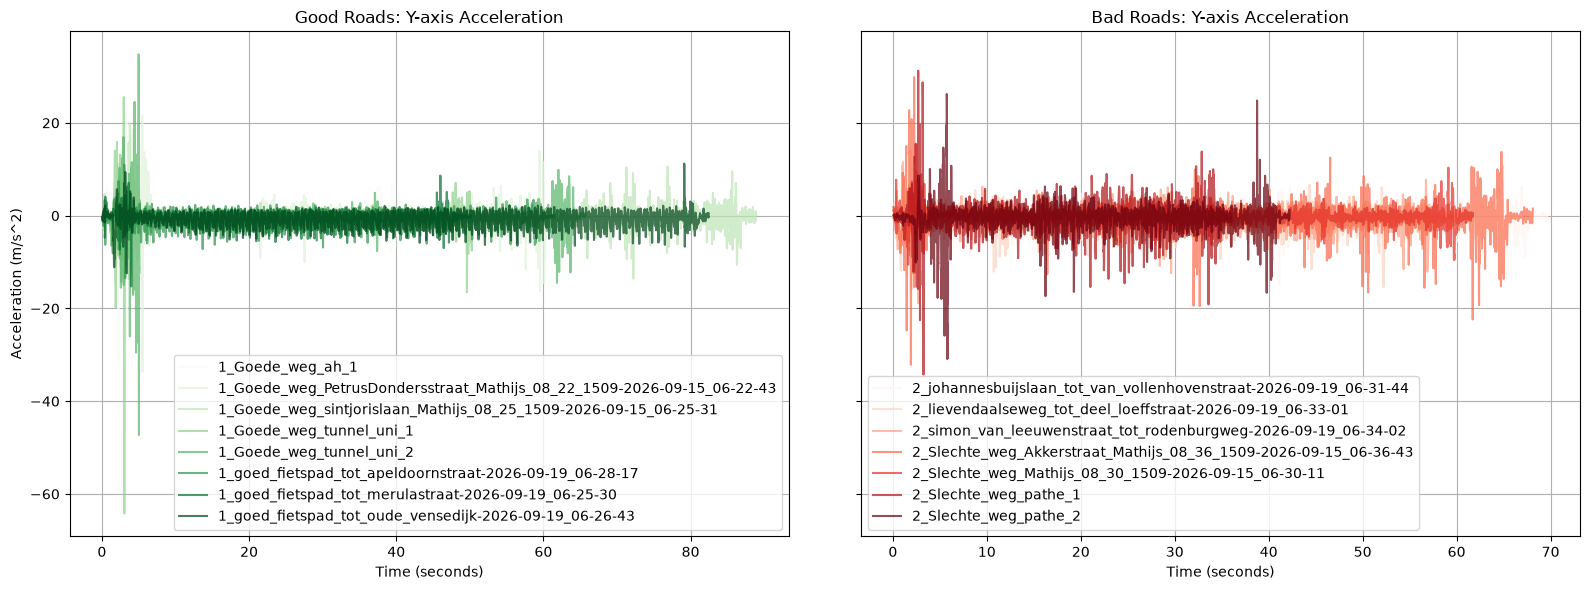

In [ ]:
data_good = pd.read_csv(r"C:\Users\20223883\OneDrive - TU Eindhoven\Desktop\Uni\Master\5ARE0 Data analysis and learning methods\5ARE0-cycling-assignment\data\Goede_weg_tunnel_uni-2026-09-10_06-35-18\Accelerometer.csv")
data_bad = pd.read_csv(r"C:\Users\20223883\OneDrive - TU Eindhoven\Desktop\Uni\Master\5ARE0 Data analysis and learning methods\5ARE0-cycling-assignment\data\Slechte_weg_pathe-2026-09-10_06-33-34\Accelerometer.csv")
print(data_good.head())
data_good.info()

In [3]:
data_good['dt'] = pd.to_datetime(data_good['time'], unit = 'ns')

In [4]:
data_good.head()

,time,seconds_elapsed,z,y,x,dt
0,1789022118626398500,0.061398,0.316404,0.050293,0.111913,2026-09-10 06:35:18.626398500
1,1789022118636323300,0.071323,0.336780,0.106358,0.264952,2026-09-10 06:35:18.636323300
2,1789022118646248200,0.081248,0.053363,0.166461,0.333310,2026-09-10 06:35:18.646248200
3,1789022118656173000,0.091173,-0.367505,0.249458,0.335399,2026-09-10 06:35:18.656173000
4,1789022118666098000,0.101098,-0.932416,0.312662,0.403675,2026-09-10 06:35:18.666098000


In [5]:
data_good.corr()

,time,seconds_elapsed,z,y,x,dt
time,1.000000,1.000000,0.003852,0.008754,-0.007890,1.000000
seconds_elapsed,1.000000,1.000000,0.003852,0.008754,-0.007890,1.000000
z,0.003852,0.003852,1.000000,-0.136641,-0.160302,0.003852
y,0.008754,0.008754,-0.136641,1.000000,-0.055622,0.008754
x,-0.007890,-0.007890,-0.160302,-0.055622,1.000000,-0.007890
dt,1.000000,1.000000,0.003852,0.008754,-0.007890,1.000000


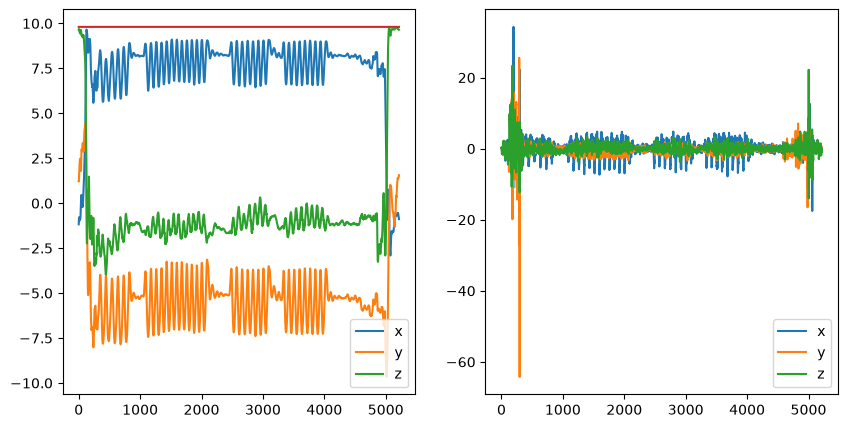

In [6]:
good_gravity_df = pd.read_csv(r"C:\Users\20223883\OneDrive - TU Eindhoven\Desktop\Uni\Master\5ARE0 Data analysis and learning methods\5ARE0-cycling-assignment\data\Goede_weg_tunnel_uni-2026-09-10_06-35-18\Gravity.csv")

total_gravity = np.sqrt(good_gravity_df['x']**2 + good_gravity_df['y']**2 + good_gravity_df['z']**2)
fig, ax = plt.subplots(ncols=2, figsize=(10, 5))
ax[0].plot(good_gravity_df['x'])
ax[0].plot(good_gravity_df['y'])
ax[0].plot(good_gravity_df['z'])
ax[0].plot(total_gravity)
ax[0].legend(['x', 'y', 'z'])

ax[1].plot(data_good['x'])
ax[1].plot(data_good['y'])
ax[1].plot(data_good['z'])
ax[1].legend(['x', 'y', 'z'])

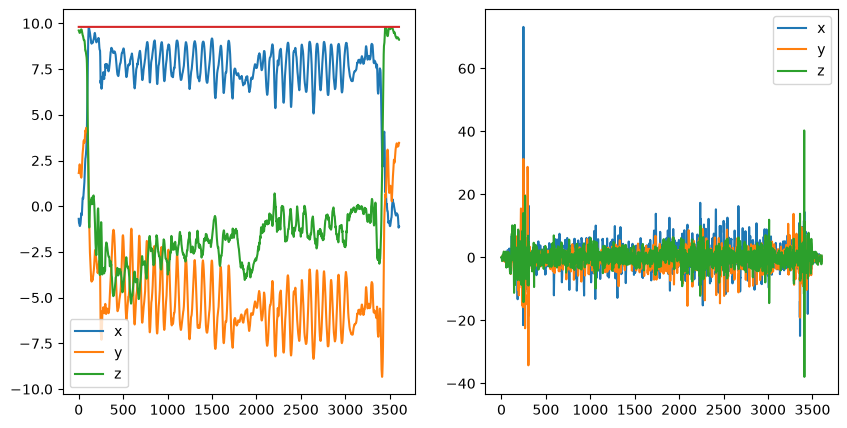

In [7]:
bad_gravity_df = pd.read_csv(r"C:\Users\20223883\OneDrive - TU Eindhoven\Desktop\Uni\Master\5ARE0 Data analysis and learning methods\5ARE0-cycling-assignment\data\Slechte_weg_pathe-2026-09-10_06-33-34\Gravity.csv")

total_gravity = np.sqrt(bad_gravity_df['x']**2 + bad_gravity_df['y']**2 + bad_gravity_df['z']**2)
fig, ax = plt.subplots(ncols=2, figsize=(10, 5))
ax[0].plot(bad_gravity_df['x'])
ax[0].plot(bad_gravity_df['y'])
ax[0].plot(bad_gravity_df['z'])
ax[0].plot(total_gravity)
ax[0].legend(['x', 'y', 'z'])

ax[1].plot(data_bad['x'])
ax[1].plot(data_bad['y'])
ax[1].plot(data_bad['z'])
ax[1].legend(['x', 'y', 'z'])

In [8]:
gyroscope = pd.read_csv(r"C:\Users\20223883\OneDrive - TU Eindhoven\Desktop\Uni\Master\5ARE0 Data analysis and learning methods\5ARE0-cycling-assignment\data\Goede_weg_tunnel_uni-2026-09-10_06-35-18\Gyroscope.csv")
gyroscope.head()

,time,seconds_elapsed,z,y,x
0,1789022118626398500,0.061398,0.065210,-0.089339,-0.183565
1,1789022118636323300,0.071323,0.100029,0.104305,-0.109650
2,1789022118646248200,0.081248,0.131794,0.268017,-0.040012
3,1789022118656173000,0.091173,0.161726,0.354149,0.032681
4,1789022118666098000,0.101098,0.162337,0.323606,0.101098


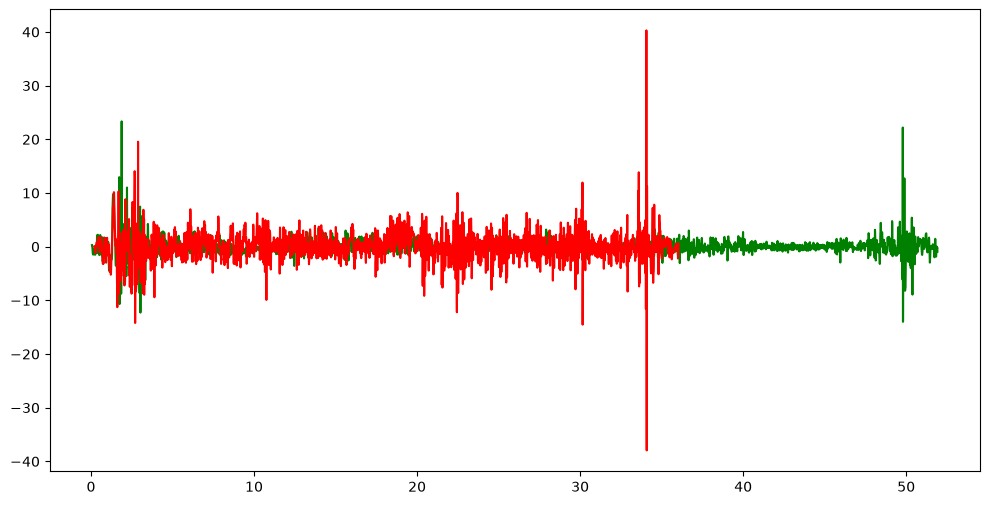

In [9]:
plt.figure(figsize=(12, 6))
plt.plot(data_good['seconds_elapsed'], data_good['z'], label='Good Road - Z-axis', color='green')
plt.plot(data_bad['seconds_elapsed'], data_bad['z'], label='Bad Road - Z-axis', color='red')

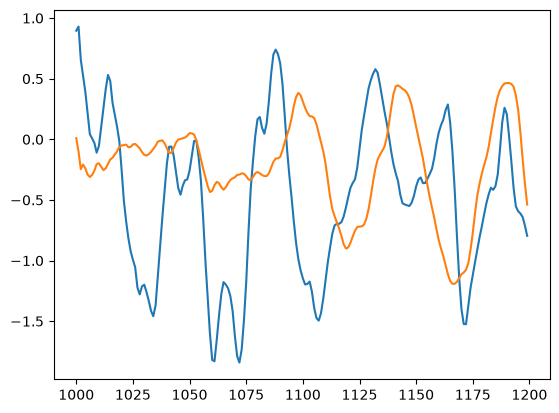

In [10]:
window_size = 20
mean_signal_bad = data_bad['y'].iloc[1000:1200].rolling(window=window_size, min_periods=1).mean()
mean_signal_good = data_good['y'].iloc[1000:1200].rolling(window=window_size, min_periods=1).mean()

plt.plot(mean_signal_bad)
plt.plot(mean_signal_good)


In [ ]:
def dci(acceleration_data):
    subset = acceleration_data.iloc[1000:3000]
    n = subset['y'][subset['y'] > 1].count()
    a = (subset['y']**2).sum()
    denom = np.sqrt((1/n) * a)
    dci = 1/denom

    return dci

print(dci(data_bad))
print(dci(data_good))


0.17647963235191846
0.2157833366504361


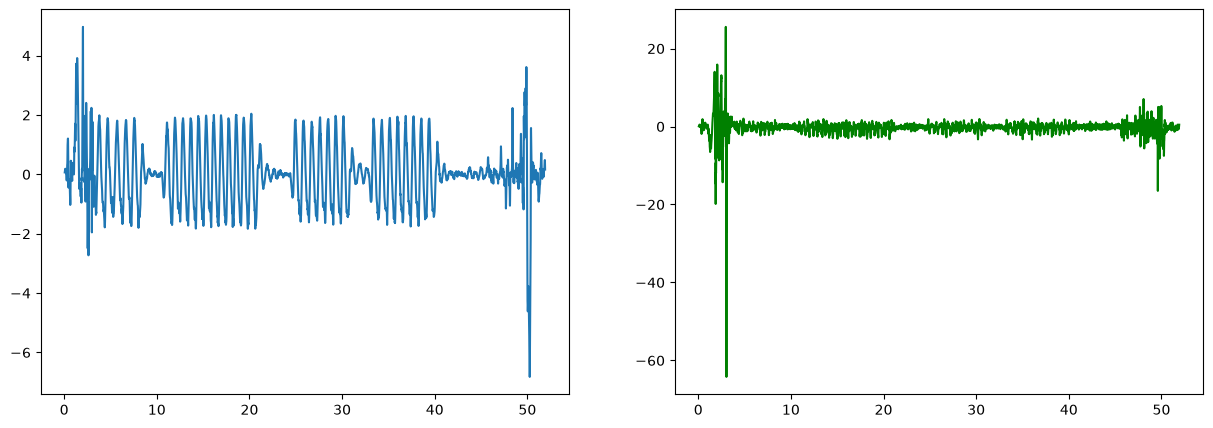

In [12]:
_, ax = plt.subplots(ncols=2, figsize=(15,5))
ax[0].plot(gyroscope["seconds_elapsed"], gyroscope["z"])
ax[1].plot(data_good['seconds_elapsed'], data_good['y'], label='Good Road - y-axis', color='green')

In [13]:
scaler = StandardScaler()
mean_signal_good = mean_signal_good.to_frame()
scaler.fit(mean_signal_good)

StandardScaler()

In [14]:
mean_signal_bad = mean_signal_bad.to_frame()
scaler.fit(mean_signal_bad)

StandardScaler()

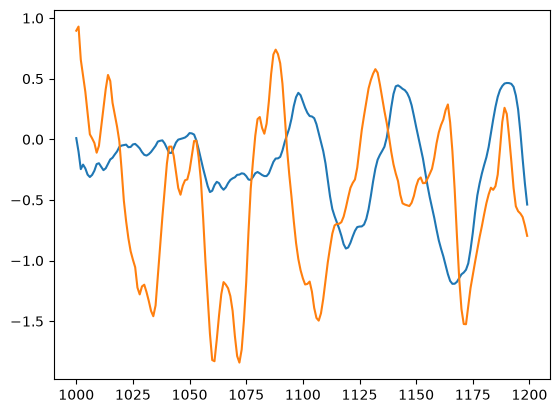

In [15]:
plt.plot(mean_signal_good)
plt.plot(mean_signal_bad)

## Frequency analysis

(0.0, 0.35)

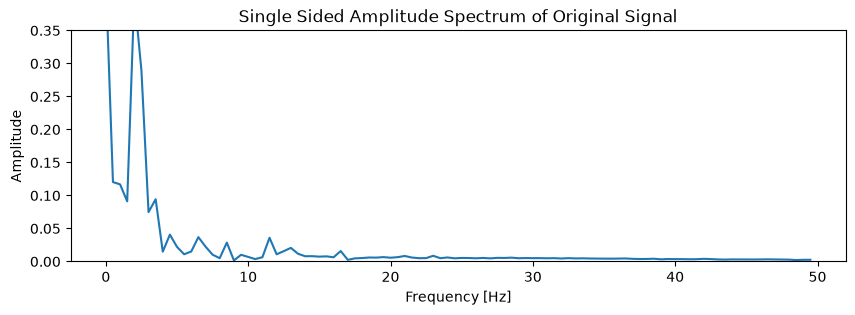

In [16]:
# Perform data conditioning on the same signal function as before
from scipy.fft import fft, fftfreq

fs = 100 # Hz
N = len(mean_signal_good['y'])

zf = fft(mean_signal_good['y'])
xf = fftfreq(N, 1/fs)

# 4. Plot the single sided frequency/amplitude spectrum
plt.figure(figsize=(10, 3))
plt.plot(xf[:N//2], 2.0/N * abs(zf[:N//2]))
plt.xlabel('Frequency [Hz]')
plt.ylabel('Amplitude')
plt.title('Single Sided Amplitude Spectrum of Original Signal')
plt.ylim(0, 0.35)

(0.0, 0.35)

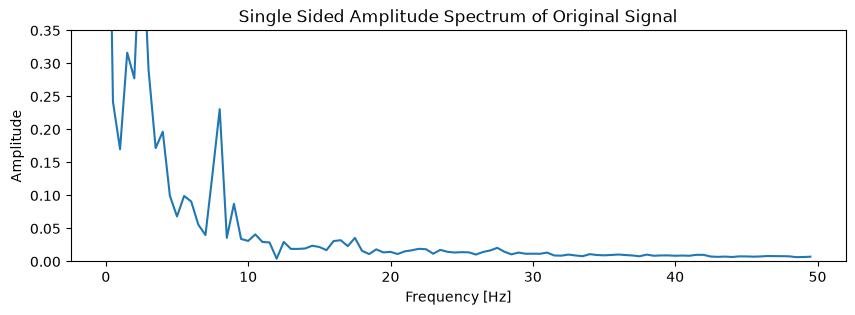

In [17]:
fs = 100 # Hz
N = len(mean_signal_bad['y'])

zf = fft(mean_signal_bad['y'])
xf = fftfreq(N, 1/fs)

# 4. Plot the single sided frequency/amplitude spectrum
plt.figure(figsize=(10, 3))
plt.plot(xf[:N//2], 2.0/N * abs(zf[:N//2]))
plt.xlabel('Frequency [Hz]')
plt.ylabel('Amplitude')
plt.title('Single Sided Amplitude Spectrum of Original Signal')
plt.ylim(0, 0.35)

(-5.0, 5.0)

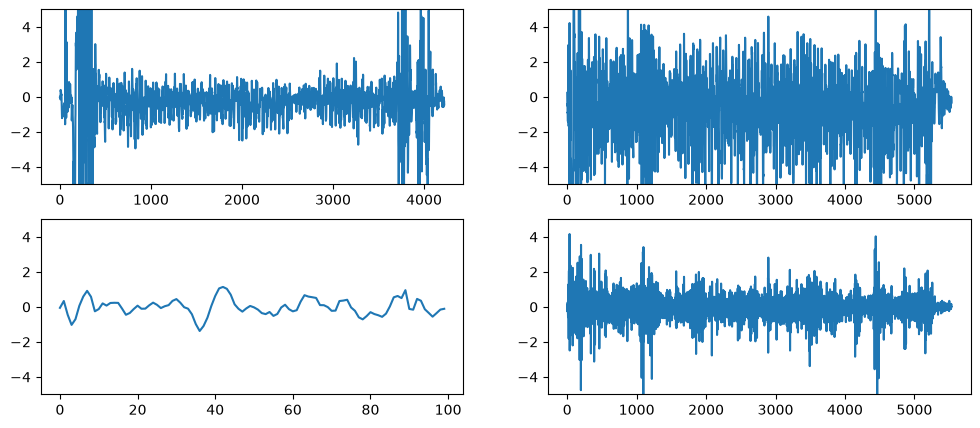

In [125]:
from scipy import signal as sg
fs = 100 # Hz
nyq = fs/2
cutoff_frequency = 3

b, a = sg.butter(4, cutoff_frequency/nyq, btype='highpass')

filtered_good = sg.filtfilt(b, a, data_good['y'].iloc[500:600])
# filtered_bad = sg.filtfilt(b, a, mean_signal_bad['y'])

fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(12, 5))
ax[0, 0].plot(data_good['y'])
ax[0,0].set_ylim([-5, 5])

ax[0, 1].plot(data_bad['y'])
ax[0,1].set_ylim([-5, 5])

ax[1, 0].plot(filtered_good)
ax[1, 0].set_ylim([-5, 5])

ax[1, 1].plot(filtered_bad)
ax[1 ,1].set_ylim([-5, 5])



(-5.0, 5.0)

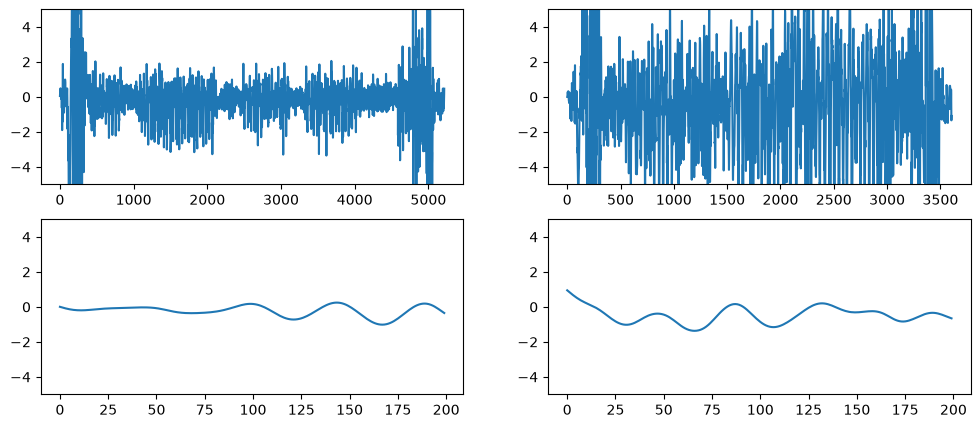

In [33]:
fs = 100 # Hz
nyq = fs/2
cutoff_frequency = 3

b, a = sg.butter(2, cutoff_frequency/nyq, btype='low')

filtered_good = sg.filtfilt(b, a, mean_signal_good['y'])
filtered_bad = sg.filtfilt(b, a, mean_signal_bad['y'])

fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(12, 5))
ax[0, 0].plot(data_good['y'])
ax[0,0].set_ylim([-5, 5])

ax[0, 1].plot(data_bad['y'])
ax[0,1].set_ylim([-5, 5])

ax[1, 0].plot(filtered_good)
ax[1, 0].set_ylim([-5, 5])

ax[1, 1].plot(filtered_bad)
ax[1 ,1].set_ylim([-5, 5])

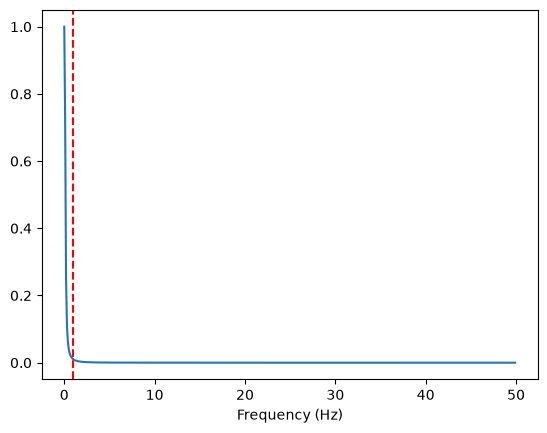

In [29]:
from scipy.signal import freqz
w, h = freqz(b, a, fs=fs)
plt.plot(w, abs(h))
plt.xlabel('Frequency (Hz)')
plt.axvline(1, color='r', linestyle='--')

In [57]:
def trim_to_30s(df):
    """Trims dataframe symmetrically to a duration of 30 seconds."""
    start_time = df['seconds_elapsed'].min()
    end_time = df['seconds_elapsed'].max()
    total_duration = end_time - start_time
    
    if total_duration > 30:
        trim_amount = (total_duration - 30) / 2
        new_start = start_time + trim_amount
        new_end = end_time - trim_amount
        
        # Filter rows within the 30-second window and reset elapsed time from 0
        df_trimmed = df[(df['seconds_elapsed'] >= new_start) & (df['seconds_elapsed'] <= new_end)].copy()
        df_trimmed['seconds_elapsed'] = df_trimmed['seconds_elapsed'] - new_start
        return df_trimmed
    return df

In [65]:
df_trimmed_good = trim_to_30s(data_good)
df_trimmed_bad = trim_to_30s(data_bad)

In [ ]:
def create_windows_and_filter(df, window_size_sec=2.0, overlap=0.5, fs=100.0):
    """Apply sliding windows"""
    df_windowed = df.copy()
    
    window_size_samples = int(window_size_sec * fs)
    step_size = int(window_size_samples * (1 - overlap))
    
    features_list = []
    
    for start in range(0, len(df) - window_size_samples, step_size):
        window = df.iloc[start:start + window_size_samples]
        sig = window['y']

        features = {
    'window_start_idx': start,
    'raw_signal': sig.values,  # stores the full array in one cell
    'mean': sig.mean(),
    'std': sig.std(),
                    }
        features_list.append(features)
    
    # Convert list of dicts into a new DataFrame — one row per window
    df_windowed = pd.DataFrame(features_list)
    
    return df_windowed

In [66]:
df_windowed_good = create_windows_and_filter(df_trimmed_good)
df_windowed_bad = create_windows_and_filter(df_trimmed_bad)

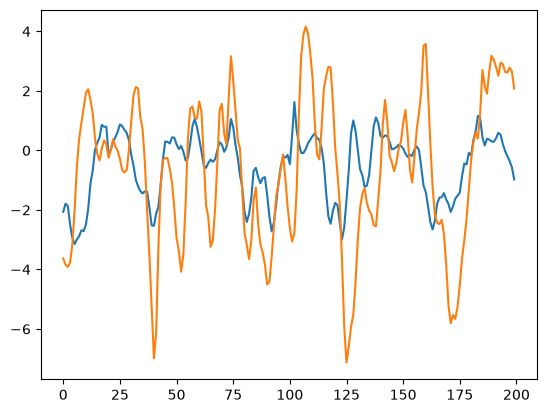

In [71]:
plt.plot(df_windowed_good['raw_signal'][4])
plt.plot(df_windowed_bad['raw_signal'][4])

<class 'pandas.Series'>
(29, 200)


(-5.0, 5.0)

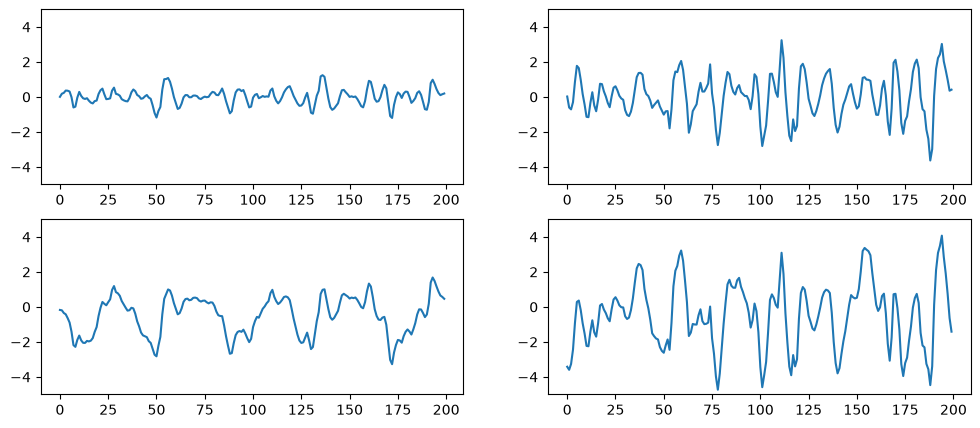

In [87]:
fs = 100 # Hz
nyq = fs/2
cutoff_frequency = 5

b, a = sg.butter(2, cutoff_frequency/nyq, btype='highpass')
print(type(df_windowed_good['raw_signal']))

filtered_good = sg.filtfilt(b, a, list(df_windowed_good['raw_signal']))
filtered_bad = sg.filtfilt(b, a, list(df_windowed_bad['raw_signal']))
print(filtered_bad.shape)

fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(12,5))
ax[0, 0].plot(filtered_good[8, :])
ax[0, 0].set_ylim([-5, 5])

ax[0, 1].plot(filtered_bad[8, :])
ax[0, 1].set_ylim([-5, 5])

ax[1, 0].plot(df_windowed_good['raw_signal'][8])
ax[1, 0].set_ylim([-5, 5])

ax[1, 1].plot(df_windowed_bad['raw_signal'][8])
ax[1, 1].set_ylim([-5, 5])

# PCA reduction

In [21]:
from sklearn.decomposition import PCA
pca = PCA(n_components=50)
pca.fit_transform(data_good["y"])

ValueError: Expected a 2-dimensional container but got <class 'pandas.Series'> instead. Pass a DataFrame containing a single row (i.e. single sample) or a single column (i.e. single feature) instead.